# llama3.1:8b — evaluation

Text-block classification into five classes, evaluated against a manually annotated
reference set of 10 Data Management Plans. PDF text extracted with pdfplumber.

Both evaluation paths are reported throughout: **Path A** scores the model's raw
structured output, **Path B** scores it after the annotation rules are applied.


## The pipeline

Where the numbers in this notebook come from. The four numbered stages are what gets
written to disk; **the two paths branch at stage 3**, which is what every table and
chart below reports side by side:

| | scores | against | folder |
|---|---|---|---|
| **Path A** | stage 3, as the model produced it | the original annotation | `3_structured/llama3.1-8b_pdfplumber_whole_doc/` |
| **Path B** | stage 4, after `Rules.xlsx` fills blank questions | the revised annotation | `4_final/llama3.1-8b_pdfplumber_whole_doc/` |

Reading the PDF (stage 1) does not depend on the model, so it is cached per extractor
and reused by all three models.


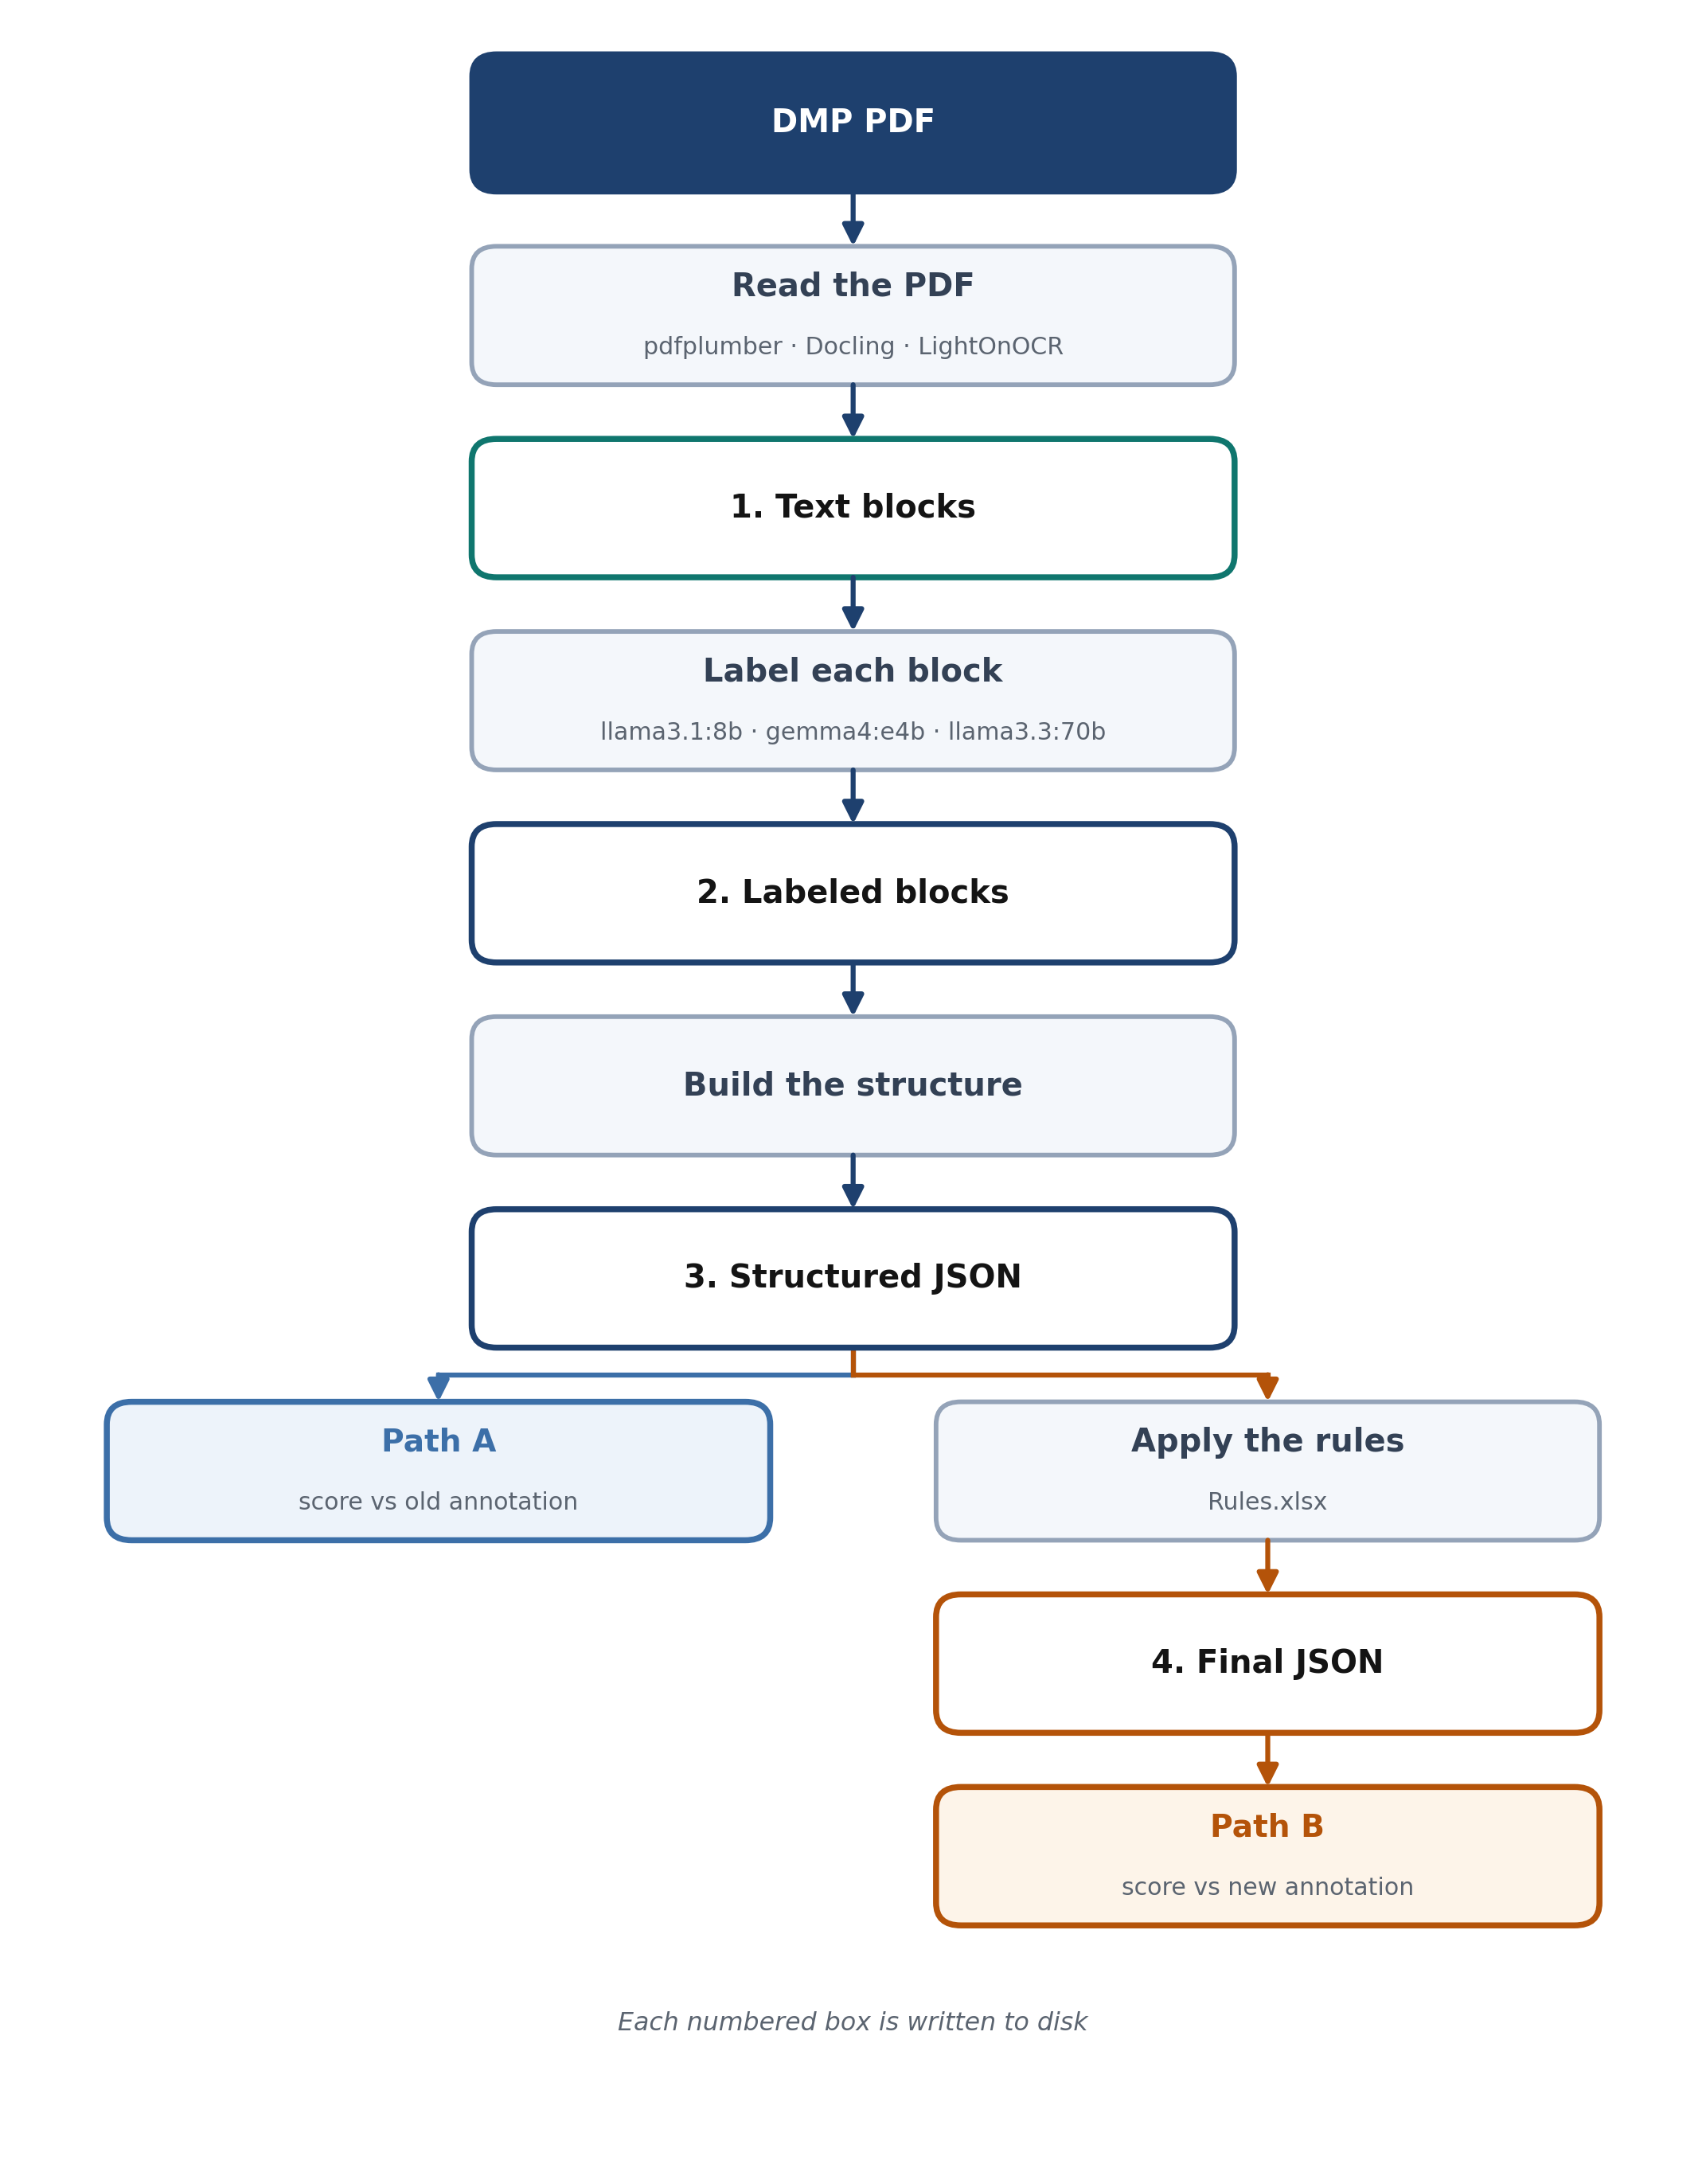

In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import Image

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

# The same flow README.md shows. Drawn with matplotlib rather than mermaid:
# GitHub renders mermaid in .md files but not inside .ipynb, and it does
# render image outputs — so this survives the trip to the repo.
DIAGRAM = Path('Report-doc/pipeline_simple.png')
if not DIAGRAM.exists():
    subprocess.run([sys.executable, 'scripts/build/make_pipeline_simple.py'],
                   check=True)

Image(str(DIAGRAM), width=700)


In [2]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import matplotlib.pyplot as plt

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, micro_prf1, compute_f1_rows, LABELS,
)
from dmpbridge.evaluation.annotation_rules import (
    load_method_new, convert_tag_to_final,
)

MODEL, TAG = 'llama3.1:8b', 'llama3.1-8b_pdfplumber_whole_doc'

# Reference categorical palette, slots 1-3 — the set validated for all pairs.
# One hue per metric, held constant across every chart and both paths.
PRECISION, RECALL, F1 = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})

# Path A — structured output vs the original annotation.
df_a, conf_a, err_a = load_method_old(TAG, exclude=[])

# Path B — rules applied, vs the revised annotation. Stage 4 is derived from
# stage 3, so build it if this tag has not been converted yet.
res_b = load_method_new(TAG, exclude=[])
if res_b[0] is None:
    convert_tag_to_final(TAG)
    res_b = load_method_new(TAG, exclude=[])
df_b, conf_b, err_b = res_b

PATHS = (('Path A', conf_a), ('Path B', conf_b))
print(f'{MODEL}')
print(f'  Path A: {len(df_a)} documents')
print(f'  Path B: {len(df_b)} documents')


llama3.1:8b
  Path A: 10 documents
  Path B: 10 documents


## 1. Metrics

Each predicted block is matched to a reference block by token overlap, giving three
possible outcomes:

| | |
|---|---|
| **TP** &nbsp;true positive | matched to a reference block, with the same class |
| **FP** &nbsp;false positive | predicted with the wrong class, or with no reference counterpart |
| **FN** &nbsp;false negative | a reference block not matched, or matched with the wrong class |

```
precision  =  TP / (TP + FP)
recall     =  TP / (TP + FN)
f1-score   =  2 * precision * recall / (precision + recall)
```

Precision falls when the model over-generates; recall falls when it under-generates.
The f1-score is their harmonic mean, so it stays low unless both are high.

Scores are **micro-averaged** — computed over the pooled counts, so every block
contributes equally regardless of how common its class is.

### The two paths

| | prediction scored | reference |
|---|---|---|
| **Path A** | stage 3, the model's structured output as produced | the original annotation |
| **Path B** | stage 4, the same output after the annotation rules are applied | the revised annotation |

Path A measures the model alone. Path B measures the model *plus* the deterministic
rules that run after it, which is what the pipeline actually delivers. The two are
scored against different reference versions, so the gap between them is the
contribution of the rules — not a second opinion on the same quantity.


llama3.1:8b — micro-averaged over 10 documents

                  Path A    Path B
----------------------------------
TP                    95        96
FP                    78        79
FN                    37        38

precision          0.549     0.549
recall             0.720     0.716
f1-score           0.623     0.621


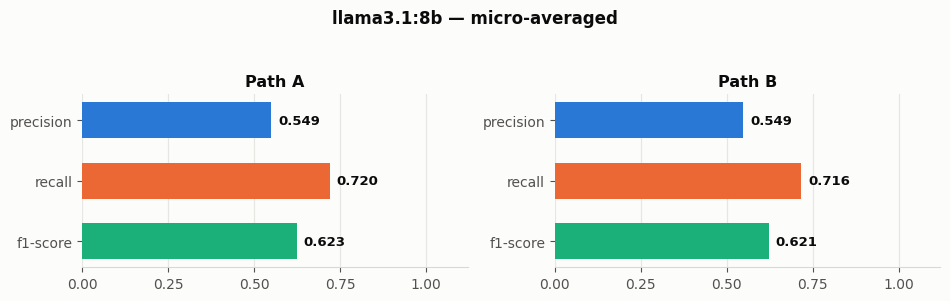

In [3]:
m_a, m_b = micro_prf1(conf_a), micro_prf1(conf_b)

print(f'{MODEL} — micro-averaged over 10 documents')
print()
print(f"{'':<14}{'Path A':>10}{'Path B':>10}")
print('-' * 34)
for key in ('tp', 'fp', 'fn'):
    print(f'{key.upper():<14}{m_a[key]:>10}{m_b[key]:>10}')
print()
for key in ('precision', 'recall', 'f1'):
    name = 'f1-score' if key == 'f1' else key
    print(f'{name:<14}{m_a[key]:>10.3f}{m_b[key]:>10.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.8), sharex=True)
names = ['precision', 'recall', 'f1-score']

for ax, (title, m) in zip(axes, (('Path A', m_a), ('Path B', m_b))):
    vals = [m['precision'], m['recall'], m['f1']]
    bars = ax.barh(names, vals, color=[PRECISION, RECALL, F1], height=0.6)
    for b, v in zip(bars, vals):
        ax.text(v + 0.02, b.get_y() + b.get_height() / 2, f'{v:.3f}',
                va='center', fontweight='bold', color=INK, fontsize=9.5)
    ax.set_xlim(0, 1.12)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(axis='x', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    ax.invert_yaxis()
    ax.set_title(title)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

fig.suptitle(f'{MODEL} — micro-averaged', fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()


## 2. Classification report

Precision, recall and f1-score per class, with support — the number of reference
blocks of that class. Reported in the conventional layout, once per path.

Support differs between the paths because they are scored against different reference
versions, so compare the scores rather than the raw counts.


In [4]:
pc_a = compute_f1_rows(conf_a).set_index('label')
pc_b = compute_f1_rows(conf_b).set_index('label')


def show_report(name, per_class, m):
    """Print one path's report in the conventional layout."""
    print(name)
    print(f"{'':<22}{'precision':>10}{'recall':>9}{'f1-score':>10}{'support':>9}")
    print()
    for lab, r in per_class.iterrows():
        print(f"{lab:<22}{r['precision']:>10.3f}{r['recall']:>9.3f}"
              f"{r['f1']:>10.3f}{int(r['support']):>9}")
    print()
    total = int(per_class['support'].sum())
    print(f"{'micro avg':<22}{m['precision']:>10.3f}{m['recall']:>9.3f}"
          f"{m['f1']:>10.3f}{total:>9}")
    print(f"{'macro avg':<22}{per_class['precision'].mean():>10.3f}"
          f"{per_class['recall'].mean():>9.3f}{per_class['f1'].mean():>10.3f}"
          f"{total:>9}")
    w = per_class['support'] / per_class['support'].sum()
    print(f"{'weighted avg':<22}{(per_class['precision'] * w).sum():>10.3f}"
          f"{(per_class['recall'] * w).sum():>9.3f}{(per_class['f1'] * w).sum():>10.3f}"
          f"{total:>9}")


show_report('Path A', pc_a, m_a)
print()
print()
show_report('Path B', pc_b, m_b)


Path A
                       precision   recall  f1-score  support

title                      0.900    0.900     0.900       10
section.title              0.617    0.860     0.718       43
section.description        0.556    0.625     0.588        8
question.text              0.037    0.062     0.047       16
answer.text                0.642    0.782     0.705       55

micro avg                  0.549    0.720     0.623      132
macro avg                  0.550    0.646     0.592      132
weighted avg               0.575    0.720     0.637      132


Path B
                       precision   recall  f1-score  support

title                      0.900    0.900     0.900       10
section.title              0.617    0.860     0.718       43
section.description        0.556    0.625     0.588        8
question.text              0.069    0.111     0.085       18
answer.text                0.642    0.782     0.705       55

micro avg                  0.549    0.716     0.621      134
macr

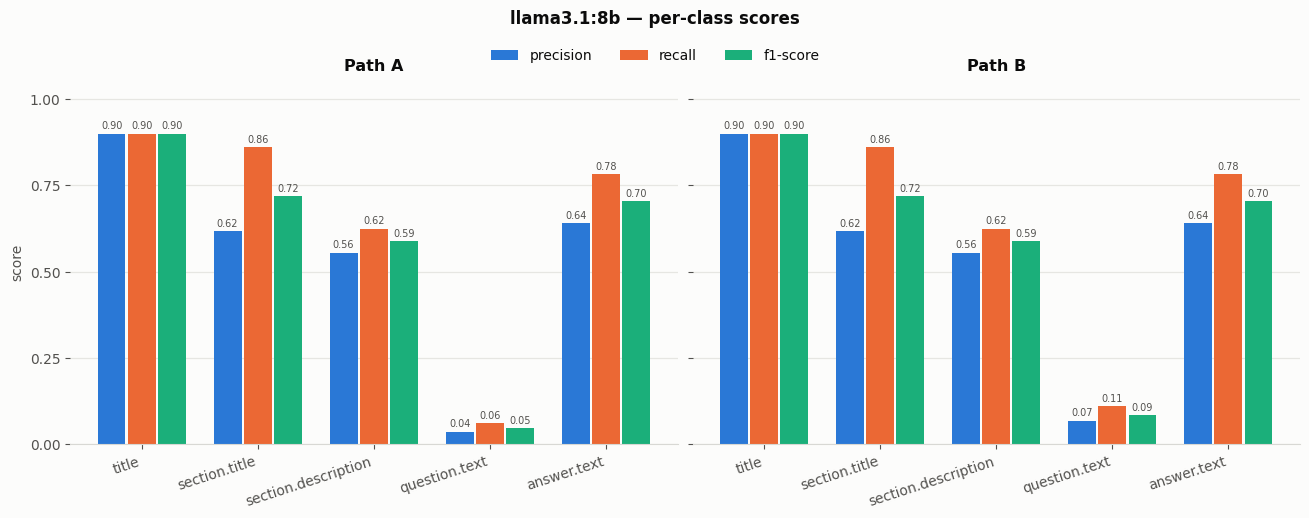

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharey=True)
w = 0.26

for ax, (title, per_class) in zip(axes, (('Path A', pc_a), ('Path B', pc_b))):
    x = np.arange(len(per_class))
    for k, (col, colour) in enumerate((('precision', PRECISION),
                                       ('recall', RECALL),
                                       ('f1', F1))):
        bars = ax.bar(x + (k - 1) * w, per_class[col], width=w - 0.02,
                      color=colour, label=col if col != 'f1' else 'f1-score')
        # Values sit above the bars: 15 bars per panel are too many to read
        # off the axis, which is left to do the comparing instead.
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7, color=MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(per_class.index, rotation=18, ha='right')
    ax.set_ylim(0, 1.06)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_title(title)
    ax.grid(axis='y', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('score')
plt.tight_layout()

# Legend and title are added after tight_layout, or it reserves no room for them.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc='upper center',
           bbox_to_anchor=(0.5, 1.00), borderaxespad=0)
fig.suptitle(f'{MODEL} — per-class scores', fontweight='bold', y=1.07)
plt.show()


## 3. Confusion matrix

Rows are the true class, columns the predicted class. Each cell counts reference blocks
of one class that were predicted as another; the diagonal counts correct classifications.

**How to read it**

- **Read across a row** to see what became of one true class. The row total is that
  class's support, and the diagonal cell divided by the row total is its **recall**.
- **Read down a column** to see everything the model gave one label to. The diagonal
  cell divided by the column total is that class's **precision**.
- **The outlined diagonal is agreement.** Everything off it is an error, and *where* it
  sits names the error: a count at row `question.text`, column `section.title` means
  real questions were labelled as headings.
- **A pair of mirrored off-diagonal cells** means two classes are being swapped for one
  another — usually a definition the prompt has not separated cleanly.
- **Comparing the two panels** shows what the annotation rules changed. A count that
  moves onto the diagonal in Path B is an error the rules repaired.

Both panels share one colour scale, so a cell of a given darkness means the same count
in either. Blocks with no counterpart on either side cannot appear in a matrix — a
prediction with no matching reference block has no true class, and a reference block the
model did not produce has no predicted class. Those are counted separately beneath, and
they are the reason a row may not sum to that class's full support.


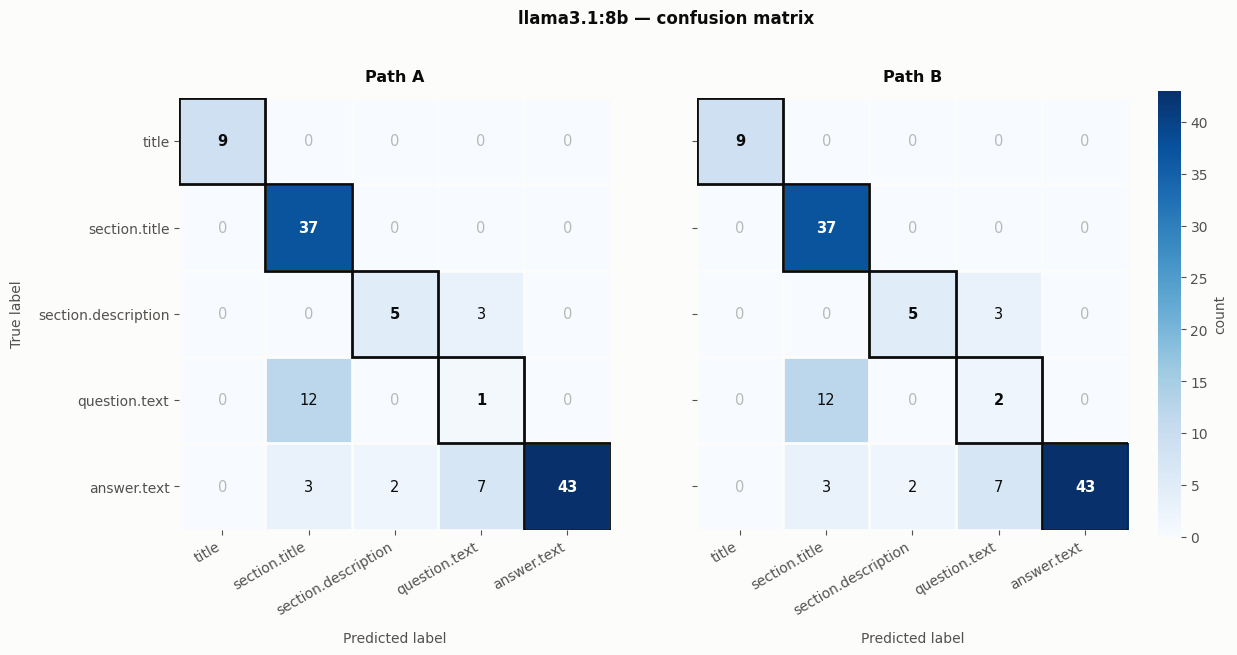

Path A
  Not representable in the matrix:
    predictions with no matching reference block     51   (FP)
    reference blocks with no matching prediction     10   (FN)
  Largest off-diagonal cells:
      12   true question.text predicted as section.title
       7   true answer.text predicted as question.text
       3   true section.description predicted as question.text
       3   true answer.text predicted as section.title

Path B
  Not representable in the matrix:
    predictions with no matching reference block     52   (FP)
    reference blocks with no matching prediction     11   (FN)
  Largest off-diagonal cells:
      12   true question.text predicted as section.title
       7   true answer.text predicted as question.text
       3   true section.description predicted as question.text
       3   true answer.text predicted as section.title



In [6]:
def build_cm(conf):
    """Square true-by-predicted count matrix over LABELS."""
    cm = np.zeros((len(LABELS), len(LABELS)), dtype=int)
    for i, true in enumerate(LABELS):
        for j, pred in enumerate(LABELS):
            cm[i, j] = conf.get(true, {}).get(pred, 0)
    return cm


cms  = [build_cm(c) for _, c in PATHS]
vmax = max(cm.max() for cm in cms)   # one scale, so the panels are comparable

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.8), sharey=True)

for ax, (title, _), cm in zip(axes, PATHS, cms):
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
    thresh = vmax * 0.55
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            v = cm[i, j]
            # Zeros are held back so the counts that matter carry the eye.
            ax.text(j, i, v, ha='center', va='center', fontsize=10.5,
                    fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v > thresh else INK))

    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_title(title, pad=12)

    # A 2px surface gap between cells, so adjacent counts read as separate marks.
    ax.set_xticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2)
    ax.tick_params(which='minor', length=0)

    # Outline the diagonal so agreement is findable without reading colour.
    # Drawn after the grid, or the grid paints over the edges.
    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                   edgecolor=INK, linewidth=2.0, zorder=5))
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('True label', labelpad=10)
fig.colorbar(im, ax=axes, fraction=0.028, pad=0.03, label='count').outline.set_visible(False)
fig.suptitle(f'{MODEL} — confusion matrix', fontweight='bold', y=1.02)
plt.show()

for (title, conf), cm in zip(PATHS, cms):
    unmatched_pred = sum(conf.get('__no_gold__', {}).values())
    unmatched_true = sum(conf.get(l, {}).get('__missed__', 0) for l in LABELS)
    print(title)
    print('  Not representable in the matrix:')
    print(f'    predictions with no matching reference block   {unmatched_pred:>4}   (FP)')
    print(f'    reference blocks with no matching prediction   {unmatched_true:>4}   (FN)')
    swaps = sorted(((cm[i, j], LABELS[i], LABELS[j])
                    for i in range(len(LABELS)) for j in range(len(LABELS))
                    if i != j and cm[i, j]), reverse=True)
    print('  Largest off-diagonal cells:')
    for count, true, pred in swaps[:4]:
        print(f'    {count:>4}   true {true} predicted as {pred}')
    print()
